In [1]:
import torch
import os
import numpy as np
from scipy.ndimage import zoom
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches

from dflat.initialize import focusing_lens, multiplexing_mask_orthrand
from dflat.metasurface import reverse_lookup_optimize, load_optical_model
from dflat.plot_utilities import format_plot
from dflat.propagation import PointSpreadFunction
from dflat.render import hsi_to_rgb, general_convolve

from diffvis.data.ARAD import ARAD

num_sets= 8
out_name = f"./gen3_psf{num_sets}/"
if not os.path.exists(out_name):
    os.mkdir(out_name)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def create_angular_masks_and_centers(dim, num_sets, radius):
    center = np.array([dim[1] // 2, dim[0] // 2])  # Center coordinates (x, y)
    y, x = np.ogrid[:dim[0], :dim[1]]
    # Compute angles adjusted to start from top-right quadrant
    angles = np.arctan2(-(y - center[1]), x - center[0]) + 2 * np.pi  # atan2 outputs range [-pi, pi]
    #angles = (angles + 7 * np.pi / 4 - 3/2*np.pi) % (2 * np.pi)  # Shift starting point to top-right quadrant
    angles = (angles + np.pi / 4 ) % (2 * np.pi)  # Shift starting point to top-right quadrant

    # Normalize the angles to fit within the range [0, num_sets)
    sector_indices = np.floor(angles / (2 * np.pi / num_sets)).astype(int)

    masks = []
    center_points = []
    for i in range(num_sets):
        mask = (sector_indices == i).astype(int)
        masks.append(mask)
        # Calculate the midpoint angle for each sector
        mid_angle = (i + 0.5) * (2 * np.pi / num_sets) + 7 * np.pi / 4
        mid_angle %= 2 * np.pi  # Ensure angle is within [0, 2*pi]
        # Calculate opposite angle for centers
        opposite_angle = mid_angle + np.pi
        opposite_angle %= 2 * np.pi  # Normalize angle
        center_x = radius * np.cos(opposite_angle)
        center_y = radius * np.sin(opposite_angle)
        center_points.append((center_x, center_y))

    return masks, center_points


(8, 1001, 1001) (8, 1001, 1001)


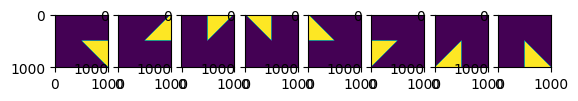

In [3]:
in_size = [1001, 1001]
in_dx_m=[4*250e-9, 4*250e-9]
out_distance = 10e-3
dx = 40

masks, offsets = create_angular_masks_and_centers(in_size, num_sets, dx)
offsets = list(np.array(offsets)*1e-6)
wavelength_set_m = np.linspace(400e-9, 650e-9, num_sets)
depth_set_m = [10 for i in range(num_sets)]

amp, phase, aperture = focusing_lens(
    in_size,
    in_dx_m,
    wavelength_set_m,
    depth_set_m,
    offsets,
    out_distance,
    aperture_radius_m=None,
    radial_symmetry=False,
)
print(amp.shape, phase.shape)

fig, ax = plt.subplots(1,num_sets)
for i in range(num_sets):
    ax[i].imshow(masks[i])


In [4]:
load_prev = True
max_steps = 450

if load_prev:
    with open(out_name + 'lens_lookup.pickle','rb') as handle:
        data = pickle.load(handle)
        shapes = data["shapes"]

else:
    list_shapes = []
    list_params = []
    for i in range(amp.shape[0]):
        param, shape, err = reverse_lookup_optimize(
            amp[i:i+1, None, None],
            phase[i:i+1,None, None],
            wavelength_set_m[i:i+1], 
            "Nanocylinders_TiO2_U250H600", 
            lr=5e-2, 
            max_iter=max_steps, 
            opt_phase_only=False
        )
        list_shapes.append(shape)
        list_params.append(param)
        # zoom_factors = [1, 3, 3, 1]  # Do not scale the batch size or channels
        # shape = zoom(shape, zoom_factors, order=3)  # order=3 for bicubic
    
    shapes = np.concatenate(list_shapes, axis=0)
    params = np.concatenate(list_params, axis=0)

    data = {"shapes": shapes, "params": params}
    with open(out_name + 'lens_lookup.pickle', 'wb') as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


(1001, 1001, 1)


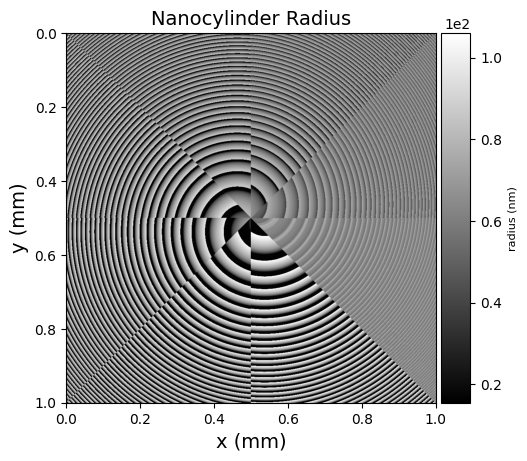

In [5]:
use_masks = np.array(masks)[...,None]
mixed_shapes = np.sum(use_masks*shapes, axis=0)
print(mixed_shapes.shape)

xvec = np.arange(mixed_shapes.shape[0])*in_dx_m[0]*1e3
fig, ax = plt.subplots(1,1)
ax.imshow(mixed_shapes*1e9, cmap='gray')
format_plot(fig, ax, "x (mm)", "y (mm)", "Nanocylinder Radius", xvec=xvec, yvec=xvec, addcolorbar=True, setAspect="equal", cbartitle="radius (nm)", fs_text=14,fs_title=14, fs_ticks=10)

data = {"mixed_shapes": mixed_shapes, "shapes": shapes}
with open(out_name + 'grouped_lens.pickle', 'wb') as handle:
    pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
sim_wl = np.linspace(400e-9, 700e-9, 31)
model = load_optical_model("Nanocylinders_TiO2_U250H600").to('cuda')
ampl, phase = model(mixed_shapes[None], sim_wl, pre_normalized=False)

Target Module: dflat.metasurface.optical_model.NeuralCells
Note: trainable_model key in NeuralCells is deprecated. Model will be set to requires_grad.
Target Module: dflat.metasurface.nn_siren.SirenNet
Target: dflat.metasurface.optical_model.NeuralCells Loading from checkpoint DFlat/Models/Nanocylinders_TiO2_U250H600/model.ckpt as strict=True
Restored dflat.metasurface.optical_model.NeuralCells with 0 missing and 0 unexpected keys


In [7]:
def vis_psf(psf_int, sim_wl, fname):
    psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True)
    psf_gs = np.sum(psf_int,axis=0)
    #xax = np.arange(out_size[0])*out_dx_m[0]*1e6

    fig = plt.figure(figsize=(6, 9))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    ax2 = fig.add_subplot(gs[2, 0])
    ax3 = fig.add_subplot(gs[2, 1])

    ax1.imshow(np.transpose(psf_rgb[0], [1,2,0]))
    format_plot(fig, ax1, xlabel="x ($\mu m$)", ylabel="y ($\mu m$)", title="PSF (RGB)", fs_text=14,fs_title=14, fs_ticks=10 )
    #format_plot(fig, ax1, xvec=xax, yvec=xax, xlabel="x ($\mu m$)", ylabel="y ($\mu m$)", title="PSF (RGB)", fs_text=14,fs_title=14, fs_ticks=10 )

    ax2.imshow(psf_gs, cmap='gray')
    format_plot(fig, ax2, title="PSF (gray)", fs_text=14,fs_title=14, fs_ticks=10 )
    #format_plot(fig, ax2, xvec=xax, yvec=xax, title="PSF (gray)", fs_text=14,fs_title=14, fs_ticks=10 )

    ax3.imshow(np.log10(psf_gs), cmap='gray')
    format_plot(fig, ax3, title="Log10(PSF) (gray)", fs_text=14,fs_title=14, fs_ticks=10 )
    #format_plot(fig, ax3, xvec=xax, yvec=xax, title="Log10(PSF) (gray)", fs_text=14,fs_title=14, fs_ticks=10 )

    plt.tight_layout()
    plt.savefig(out_name+fname+".png")
    plt.close()

    return

out_dx_m = [5e-6, 5e-6]
ps_locs = [[0.0, 0.0, 10]]
in_size = [1001, 1001]

PSF = PointSpreadFunction(
    in_size, 
    in_dx_m, 
    out_distance, 
    [64, 64], 
    out_dx_m,
    sim_wl,
    diffraction_engine='fresnel')
psfi, psfp = PSF(ampl, phase, ps_locs)
psf_int = psfi.detach().cpu().numpy().squeeze()
psf_phase = psfp.detach().cpu().numpy().squeeze()
psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True).squeeze()
psf_gs = np.sum(psf_int, axis=0)

name = "psf_compact64"
vis_psf(psf_int, sim_wl, name)
data = {"psf_int": psf_int, "wl": sim_wl, "psf_rgb": psf_rgb, "psf_gs": psf_gs}
with open(out_name + name + '.pickle', 'wb') as handle:
   pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

###
PSF = PointSpreadFunction( 
    in_size, 
    in_dx_m, 
    out_distance, 
    [32, 32], 
    out_dx_m,
    sim_wl,
    diffraction_engine='fresnel')
psfi, psfp = PSF(ampl, phase, ps_locs)
psf_int = psfi.detach().cpu().numpy().squeeze()
psf_phase = psfp.detach().cpu().numpy().squeeze()
psf_rgb = hsi_to_rgb(psf_int[None], sim_wl, demosaic=False, tensor_ordering=True).squeeze()
psf_gs = np.sum(psf_int, axis=0)

name = "psf_compact32"
vis_psf(psf_int, sim_wl, name)
data = {"psf_int": psf_int, "wl": sim_wl, "psf_rgb": psf_rgb, "psf_gs": psf_gs}
with open(out_name + name + '.pickle', 'wb') as handle:
   pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)
